# Solution 20: PYMC and Gibbs Sampling

## 1. Using MCMC for inference on Binary Networks

Given the factorised distribution

$P(C,R,D,A,S,F,T) = P(R)P(C)P(D)P(A\vert C)P(F\vert A)P(T\vert F,D) P(S\vert F,T)$

and the univariate distributions given in the code cell below, compute the following quantities using `pymc`. Verify your answers against the exact solutions computed in Exercise 16, and the direct sampling solutions computed in Exercise 17.

In [27]:
import numpy as np
PR = np.array([0.7,0.3])
PC = np.array([0.9,0.1])
PD = np.array([0.5,0.5])
PA_C = np.array([[1.0, 0.99],[0.0,0.01]])
PF_A = np.array([[0.999, 0.7],[0.001,0.3]])
PT_FD = np.array([[[0.99,0.40],[0.30,0.01]],[[0.01,0.60],[0.70,0.99]]])
PS_TF = np.array([[[0.999,0.01],[0.70,0.01]],[[0.001,0.99],[0.30,0.99]]])


In [28]:
import pymc as mc

with mc.Model() as model:
    R = mc.Bernoulli('R', PR[1])
    C = mc.Bernoulli('C', PC[1])
    D = mc.Bernoulli('D', PD[1])
    PA = mc.Deterministic('PA', mc.math.switch(C, PA_C[:,1], PA_C[:,0]))
    A = mc.Bernoulli('A', PA[1])
    PF = mc.Deterministic('PF', mc.math.switch(A, PF_A[:,1], PF_A[:,0]))
    F = mc.Bernoulli('F', PF[1])
    PT_F = mc.Deterministic('PT_F', mc.math.switch(D, PT_FD[:,:,1], PT_FD[:,:,0]))
    PT = mc.Deterministic('PT', mc.math.switch(F, PT_F[:,1], PT_F[:,0]))
    T = mc.Bernoulli('T', PT[1])
    PS_T = mc.Deterministic('PS_T', mc.math.switch(F, PS_TF[:,:,1], PS_TF[:,:,0]))
    PS = mc.Deterministic('PS', mc.math.switch(T, PS_T[:,1], PS_T[:,0]))
    S = mc.Bernoulli('S', PS[1])
    trace = mc.sample(500000, tune=1000, chains=4, random_seed=42)


Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [R, C, D, A, F, T, S]


Output()

Sampling 4 chains for 1_000 tune and 500_000 draw iterations (4_000 + 2_000_000 draws total) took 220 seconds.


array([[<Axes: title={'center': 'R'}>, <Axes: title={'center': 'R'}>],
       [<Axes: title={'center': 'C'}>, <Axes: title={'center': 'C'}>],
       [<Axes: title={'center': 'D'}>, <Axes: title={'center': 'D'}>],
       [<Axes: title={'center': 'A'}>, <Axes: title={'center': 'A'}>],
       [<Axes: title={'center': 'F'}>, <Axes: title={'center': 'F'}>],
       [<Axes: title={'center': 'T'}>, <Axes: title={'center': 'T'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'S'}>],
       [<Axes: title={'center': 'PA'}>, <Axes: title={'center': 'PA'}>],
       [<Axes: title={'center': 'PF'}>, <Axes: title={'center': 'PF'}>],
       [<Axes: title={'center': 'PT_F'}>,
        <Axes: title={'center': 'PT_F'}>],
       [<Axes: title={'center': 'PT'}>, <Axes: title={'center': 'PT'}>],
       [<Axes: title={'center': 'PS_T'}>,
        <Axes: title={'center': 'PS_T'}>],
       [<Axes: title={'center': 'PS'}>, <Axes: title={'center': 'PS'}>]],
      dtype=object)

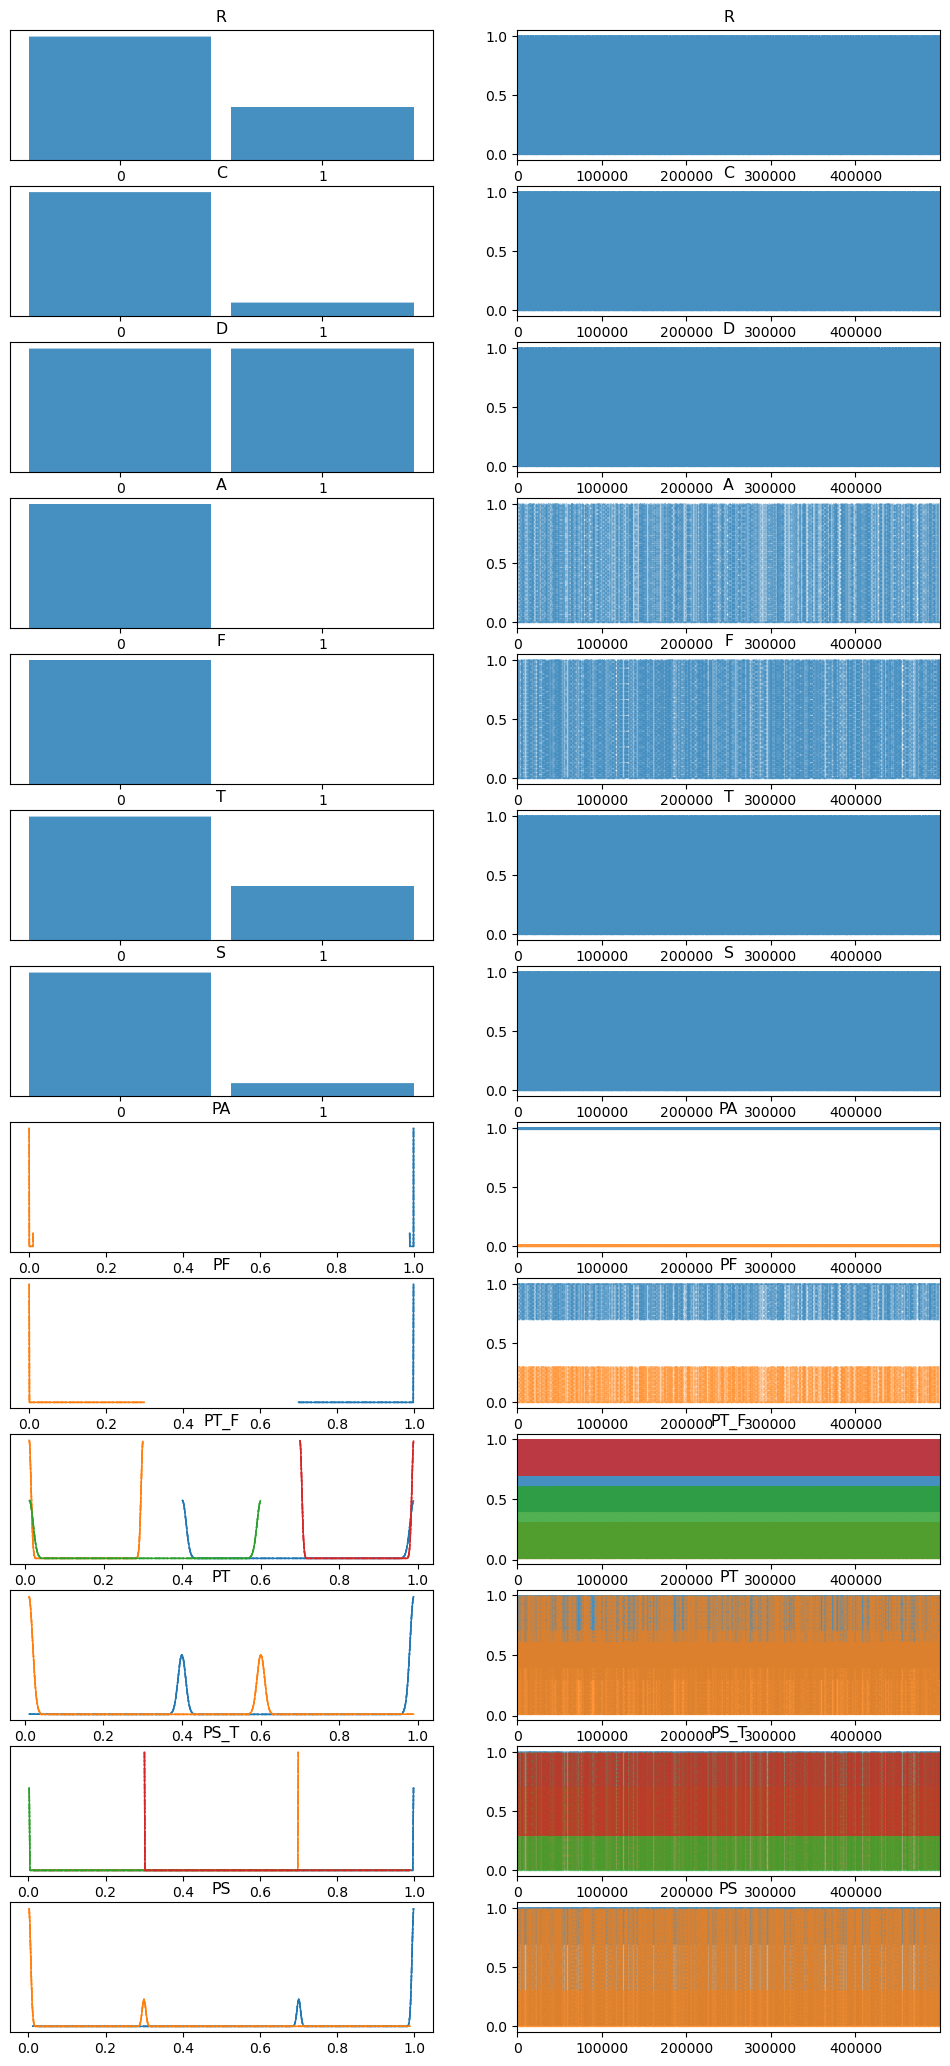

In [29]:
mc.plot_trace(trace)

In [30]:
df = trace.to_dataframe(groups='posterior')
display(df)

,chain,draw,R,C,D,A,F,T,S,"(PA[0], 0)",...,"(PT_F[1,0], 1, 0)","(PT_F[1,1], 1, 1)","(PT[0], 0)","(PT[1], 1)","(PS_T[0,0], 0, 0)","(PS_T[0,1], 0, 1)","(PS_T[1,0], 1, 0)","(PS_T[1,1], 1, 1)","(PS[0], 0)","(PS[1], 1)"
0,0,0,0,0,1,0,0,1,0,1.0,...,0.60,0.99,0.40,0.60,0.999,0.7,0.001,0.3,0.700,0.300
1,0,1,0,0,1,0,0,0,0,1.0,...,0.60,0.99,0.40,0.60,0.999,0.7,0.001,0.3,0.999,0.001
2,0,2,0,0,1,0,0,1,1,1.0,...,0.60,0.99,0.40,0.60,0.999,0.7,0.001,0.3,0.700,0.300
3,0,3,1,0,1,0,0,1,0,1.0,...,0.60,0.99,0.40,0.60,0.999,0.7,0.001,0.3,0.700,0.300
4,0,4,0,0,1,0,0,0,0,1.0,...,0.60,0.99,0.40,0.60,0.999,0.7,0.001,0.3,0.999,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,3,499995,1,0,0,0,0,0,0,1.0,...,0.01,0.70,0.99,0.01,0.999,0.7,0.001,0.3,0.999,0.001
1999996,3,499996,0,0,0,0,0,0,0,1.0,...,0.01,0.70,0.99,0.01,0.999,0.7,0.001,0.3,0.999,0.001
1999997,3,499997,0,0,0,0,0,0,0,1.0,...,0.01,0.70,0.99,0.01,0.999,0.7,0.001,0.3,0.999,0.001
1999998,3,499998,1,0,0,0,0,0,0,1.0,...,0.01,0.70,0.99,0.01,0.999,0.7,0.001,0.3,0.999,0.001


1. $P(S)$

In [31]:

print(f"P(S) = {len(df[df['S']==1])/len(df)} (expect 0.09357)")

P(S) = 0.0938615 (expect 0.09357)


2. $P(S,C)$

In [32]:
print(f"P(S) = {df[(df['S']==1) & (df['C']==1)].shape[0]/df.shape[0]} (expect 0.00953)")

P(S) = 0.009659 (expect 0.00953)


3. $P(A\vert S)$

In [37]:
print(f"P(S) = {df[(df['A']==1) & (df['S']==1)].shape[0]/df[df['S']==1].shape[0]} (expect 0.001514)")

P(S) = 0.0037874954054644343 (expect 0.001514)


4. $P(A\vert T)$

In [39]:
print(f"P(S) = {df[(df['A']==1) & (df['T']==1)].shape[0]/df[df['T']==1].shape[0]} (expect 0.0.00153)")

P(S) = 0.0015022394798332515 (expect 0.0.00153)


## 2. A Multi-valued Problem

Consider the following problem:

You are very proud of your garden and like to keep it well watered, but you don't like to be wasteful. You have a garden sprinkler that you use when it is necessary,


* You are very unlikely to turn on the sprinkler when it is raining, somewhat likely when it is cloudy and very likely when it is sunny.
* Where you live, it is quite likely be sunny, somewhat likely to be cloudy, and unlikely to be raining.
* Whether the grass is wet depends both on the weather and on whether you have used the sprinkler.
* The sprinkler has 3 settings, `off`, `low`, `high`

We can model this using the following network, with random variables $S$ (sprinkler), $W$ (weather) and $G$ (Grass):


$P(S,G,W) = P(G\vert S,W)P(S\vert W)P(W)$

The probabilities can be estimated as:

| $P(W=0)$ | $P(W=1)$ | $P(W=2)$ |
|:---------|:---------|:---------|
| $0.5$    | $0.3$    | $0.2$    |

with $W=0$: sunny; $W=1$: cloudy; $W=2$: raining

|       | $P(S=0\vert W)$ | $P(S=1\vert W)$ | $P(S=2\vert W)$ |
|:------|:---------|:---------|:---------|
| $W=0$ | $0.5$    | $0.3$    | $0.9$    |      
| $W=1$ | $0.7$    | $0.2$    | $0.1$    |
| $W=2$ | $0.9$    | $0.1$    | $0.0$    |

with $S=0$: off; $S=1$: low; $S=2$: high

|            | $P(G=0\vert W,S)$ | $P(G=1\vert W,S)$ | $P(G=2\vert W,s)$ |
|:-----------|:------------------|:------------------|:------------------|
| $W=0, S=0$ | $0.9$             | $0.1$            | $0.0$             |      
| $W=0, S=1$ | $0.5$             | $0.4$            | $0.1$             |
| $W=0, S=2$ | $0.2$             | $0.5$            | $0.3$             |
| $W=1, S=0$ | $0.8$             | $0.2$            | $0.0$             |
| $W=2, S=1$ | $0.4$             | $0.5$            | $0.1$             |
| $W=1, S=2$ | $0.2$             | $0.5$            | $0.3$             |
| $W=2, S=0$ | $0.7$             | $0.2$            | $0.1$             |
| $W=2, S=1$ | $0.3$             | $0.4$            | $0.3$             |
| $W=2, S=2$ | $0.1$             | $0.3$            | $0.6$             |

with $G=0$: dry; $G=1$: damp; $G=2$: wet


Compute the posterior distribution of $P(G)$.

In [41]:
import pymc as mc
import pytensor.tensor as pt
import numpy as np

# States
weather_states = ["sunny", "cloudy", "rainy"]
sprinkler_states = ["off", "low", "high"]
grass_states = ["dry", "damp", "soaked"]

n_weather = len(weather_states)
n_sprinkler = len(sprinkler_states)
n_grass = len(grass_states)

# Prior P(Weather)
PW = np.array([0.5, 0.3, 0.2])

# CPT: P(Sprinkler | Weather)
PS_W = np.array([
    [0.6, 0.3, 0.1],   # sunny
    [0.7, 0.2, 0.1],   # cloudy
    [0.9, 0.1, 0.0],   # rainy
])

# CPT: P(GrassWet | Weather, Sprinkler)
# shape (3,3,3): weather × sprinkler × grass
PG_SW = np.array([
    # weather = sunny
    [
        [0.9, 0.1, 0.0],   # off
        [0.5, 0.4, 0.1],   # low
        [0.2, 0.5, 0.3],   # high
    ],
    # weather = cloudy
    [
        [0.8, 0.2, 0.0],
        [0.4, 0.5, 0.1],
        [0.2, 0.5, 0.3],
    ],
    # weather = rainy
    [
        [0.7, 0.2, 0.1],
        [0.3, 0.4, 0.3],
        [0.1, 0.3, 0.6],
    ]
])

with mc.Model() as model:
    W = mc.Categorical("W", PW)
    P_S = pt.take(PS_W, W, axis=0)
    S = mc.Categorical("S", P_S)
    PG_S = pt.take(PG_SW, W, axis=0)
    P_G = pt.take(PG_S, S, axis=0)
    G = mc.Categorical("G", P_G)

    trace = mc.sample(10000, tune=1000, chains=4, random_seed=42)


Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [W, S, G]


Output()

Sampling 4 chains for 0 tune and 11_000 draw iterations (0 + 44_000 draws total) took 2 seconds.


array([[<Axes: title={'center': 'W'}>, <Axes: title={'center': 'W'}>],
       [<Axes: title={'center': 'S'}>, <Axes: title={'center': 'S'}>],
       [<Axes: title={'center': 'G'}>, <Axes: title={'center': 'G'}>]],
      dtype=object)

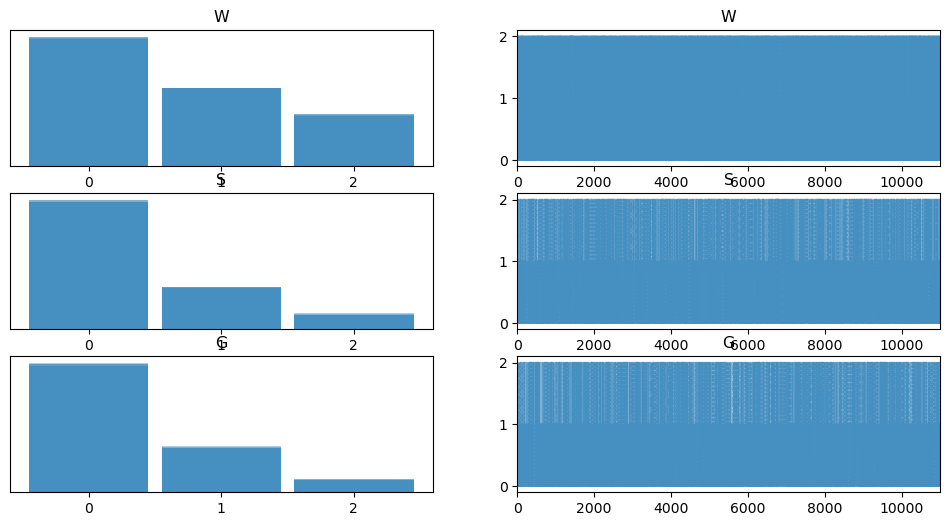

In [42]:
mc.plot_trace(trace)

In [45]:
df = trace.to_dataframe(groups='posterior')
print(f"P(G) = {df[df['G']==1].shape[0]/df.shape[0]}")

P(G) = 0.2424318181818182
